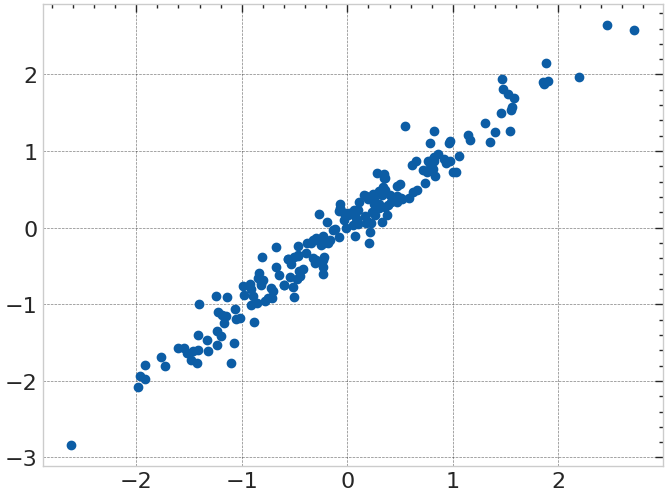

In [83]:
plt.plot(data['x_true'],np.mean(bhm_samples['x_true'],axis = 0), 'o', label='BHM inferred x_true mean')

/tmp/ipykernel_93041/2286444350.py:183: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(



REGRESSION DILUTION BIAS AND BAYESIAN HIERARCHICAL MODEL CORRECTION
Using NumPyro for Bayesian Inference

[1/4] Generating synthetic data with measurement error...
[2/4] Running naive regression (this will be biased)...
[3/4] Running Bayesian Hierarchical Model (this corrects the bias)...
        Sampling from posterior using NUTS (No-U-Turn Sampler)...


sample: 100%|██████████| 9000/9000 [00:02<00:00, 4398.84it/s, 15 steps of size 2.61e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
      alpha      2.38      0.12      2.38      2.18      2.59   2823.69      1.00
       mu_x     -0.02      0.07     -0.02     -0.14      0.09  52413.83      1.00
    sigma_x      2.39      1.81      2.02      0.00      4.96  44191.58      1.00
  x_true[0]      0.57      0.21      0.57      0.22      0.90  45867.49      1.00
  x_true[1]     -0.03      0.21     -0.03     -0.37      0.31  48394.69      1.00
  x_true[2]      0.87      0.21      0.86      0.52      1.21  33680.85      1.00
  x_true[3]      1.75      0.22      1.74      1.39      2.12  14824.94      1.00
  x_true[4]     -0.51      0.21     -0.51     -0.84     -0.17  44861.01      1.00
  x_true[5]     -0.42      0.21     -0.42     -0.77     -0.09  45033.62      1.00
  x_true[6]      1.69      0.22      1.69      1.33      2.05  14930.71      1.00
  x_true[7]      0.88      0.21      0.87      0.54      1.22  32147.06      1.00
  x_true[8]    

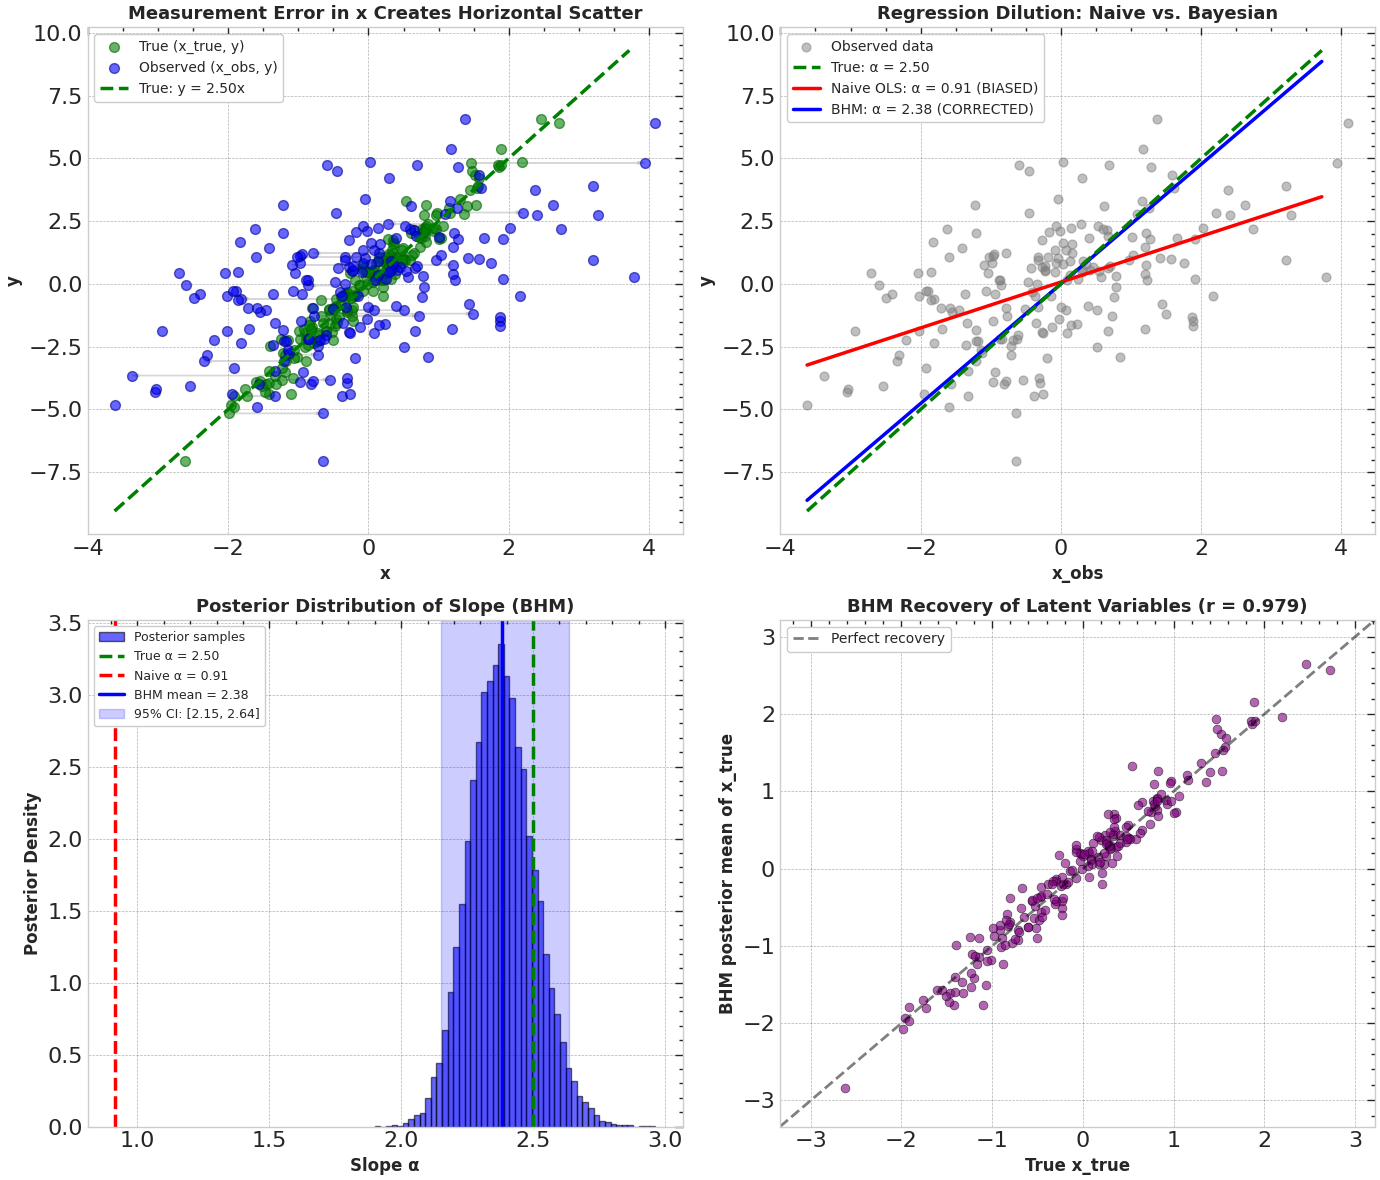


CONCLUSION

The Bayesian Hierarchical Model successfully corrects regression dilution bias by:

1. Explicitly modeling measurement error in x_obs
2. Treating true values x_true as latent variables
3. Jointly inferring x_true and α from the data
4. Marginalizing over uncertainty in x_true

This is superior to naive regression, which ignores measurement error and
produces systematically biased (attenuated) slope estimates.
    


In [84]:
"""
Demonstration of Regression Dilution Bias and Bayesian Hierarchical Model Correction

This code shows:
1. How measurement error in the independent variable causes regression dilution
2. How a Bayesian Hierarchical Model (BHM) corrects this bias by treating
   the true x values as latent variables and marginalizing over them

Uses NumPyro for better compatibility with modern Python versions
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# NumPyro imports
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])
# Set random seeds for reproducibility
np.random.seed(42)
jax.config.update('jax_platform_name', 'gpu')

# ============================================================================
# PART 1: DATA GENERATION
# ============================================================================

def generate_data_with_measurement_error(n_samples=200):
    """
    Generate synthetic data with measurement error in x
    
    Model:
        x_true ~ N(0, σ_x²)
        y = α_true * x_true + ε_y,  ε_y ~ N(0, σ_y²)
        x_obs = x_true + ε_x,  ε_x ~ N(0, σ_x_meas²)
    
    We choose σ_x_meas ≈ σ_x so regression dilution is significant
    """
    
    # True parameters
    alpha_true = 2.5  # True slope
    sigma_x = 1  # Standard deviation of true x distribution
    sigma_y = 0.5     # Intrinsic scatter in y
    sigma_x_meas = 1.2  # Measurement error in x (comparable to σ_x!)
    
    # Generate latent (true) x values
    x_true = np.random.normal(0, sigma_x, n_samples)
    
    # Generate true y values from the linear relation
    epsilon_y = np.random.normal(0, sigma_y, n_samples)
    y = alpha_true * x_true + epsilon_y
    
    # Generate observed x with measurement error
    epsilon_x = np.random.normal(0, sigma_x_meas, n_samples)
    x_obs = x_true + epsilon_x
    
    data = {
        'x_true': x_true,
        'x_obs': x_obs,
        'y': y,
        'alpha_true': alpha_true,
        'sigma_x': sigma_x,
        'sigma_y': sigma_y,
        'sigma_x_meas': sigma_x_meas
    }
    
    return data


# ============================================================================
# PART 2: NAIVE REGRESSION (DEMONSTRATES THE BIAS)
# ============================================================================

def naive_regression(x_obs, y):
    """
    Perform naive least-squares regression of y on x_obs
    
    This is BIASED because we ignore measurement error in x_obs.
    
    Theory: When x has measurement error, the estimated slope is attenuated by
    the factor λ = Var(x_true) / [Var(x_true) + Var(ε_x)]
    
    So: α_naive ≈ λ * α_true < α_true
    """
    
    # Ordinary least squares
    n = len(x_obs)
    x_mean = np.mean(x_obs)
    y_mean = np.mean(y)
    
    # Slope: β = Cov(x,y) / Var(x)
    numerator = np.sum((x_obs - x_mean) * (y - y_mean))
    denominator = np.sum((x_obs - x_mean)**2)
    alpha_naive = numerator / denominator
    
    # Intercept (not our focus, but include for completeness)
    beta_naive = y_mean - alpha_naive * x_mean
    
    # Predictions
    y_pred = alpha_naive * x_obs + beta_naive
    
    # Standard error (for reference)
    residuals = y - y_pred
    mse = np.sum(residuals**2) / (n - 2)
    se_alpha = np.sqrt(mse / np.sum((x_obs - x_mean)**2))
    
    return {
        'alpha': alpha_naive,
        'beta': beta_naive,
        'se_alpha': se_alpha,
        'y_pred': y_pred
    }


def calculate_theoretical_attenuation(sigma_x, sigma_x_meas):
    """
    Calculate the theoretical attenuation factor
    
    λ = σ_x² / (σ_x² + σ_x_meas²)
    
    The naive estimator gives: α_naive ≈ λ * α_true
    """
    lambda_factor = sigma_x**2 / (sigma_x**2 + sigma_x_meas**2)
    return lambda_factor


# ============================================================================
# PART 3: BAYESIAN HIERARCHICAL MODEL (NumPyro)
# ============================================================================

def bhm_model(x_obs, y, sigma_x, sigma_y, sigma_x_meas):
    """
    Bayesian Hierarchical Model that corrects for measurement error
    
    Model structure:
        x_true[i] ~ N(0, σ_x²)              [Latent true values]
        x_obs[i] ~ N(x_true[i], σ_x_meas²)  [Measurement model]
        y[i] ~ N(α * x_true[i], σ_y²)       [True relationship]
    
    By treating x_true as latent variables and marginalizing over them,
    we correctly account for measurement error and recover the true slope α.
    """
    
    n_data = len(x_obs)
    
    # Prior on the slope α
    # We use a broad prior since we want to learn this from data
    alpha = numpyro.sample('alpha', dist.HalfNormal(5))
    
    # Latent true x values
    # These are sampled from the population distribution
    # Key insight: We don't observe these directly!
    simga_x = numpyro.sample('sigma_x',dist.HalfNormal(3.0))
    mu_x = numpyro.sample("mu_x",dist.Normal(0, 2))
    with numpyro.plate('data', n_data):
        
        x_true = numpyro.sample('x_true', dist.Normal(mu_x, sigma_x))
        
        # Measurement model: x_obs given x_true
        # This connects our observations to the latent variables
        #numpyro.sample('x_obs', dist.Normal(x_true, sigma_x_meas), obs=x_obs)
        
        # True relationship: y given x_true
        # This is where the slope α appears
        mu_y = alpha * x_true
        numpyro.sample('y', dist.Normal(mu_y, sigma_y), obs=y)


def run_bayesian_inference(x_obs, y, sigma_x, sigma_y, sigma_x_meas,
                           n_samples=15000, n_warmup=10000):
    """
    Run MCMC sampling for the Bayesian Hierarchical Model
    """
    
    # Set up the NUTS sampler
    nuts_kernel = NUTS(bhm_model)
    
    # Run MCMC
    mcmc = MCMC(
        nuts_kernel,
        num_warmup=n_warmup,
        num_samples=n_samples,
        num_chains=4,
        progress_bar=True
    )
    
    # Convert to JAX arrays
    x_obs_jax = jnp.array(x_obs)
    y_jax = jnp.array(y)
    
    # Run the sampler
    rng_key = jax.random.PRNGKey(532)
    mcmc.run(rng_key, x_obs_jax, y_jax, sigma_x, sigma_y, sigma_x_meas)
    
    # Get samples
    samples = mcmc.get_samples()
    
    # Print diagnostics
    mcmc.print_summary()
    
    return samples, mcmc


# ============================================================================
# PART 4: COMPARISON AND VISUALIZATION
# ============================================================================

def compare_methods(data, naive_result, bhm_samples):
    """
    Compare true slope, naive regression, and BHM results
    """
    
    alpha_true = data['alpha_true']
    alpha_naive = naive_result['alpha']
    
    # Extract posterior samples for α
    alpha_posterior = np.array(bhm_samples['alpha'])
    alpha_bhm_mean = np.mean(alpha_posterior)
    alpha_bhm_std = np.std(alpha_posterior)
    alpha_bhm_ci = np.percentile(alpha_posterior, [2.5, 97.5])
    
    # Calculate theoretical attenuation
    lambda_theoretical = calculate_theoretical_attenuation(
        data['sigma_x'], data['sigma_x_meas']
    )
    alpha_theoretical_biased = lambda_theoretical * alpha_true
    
    print("=" * 80)
    print("REGRESSION DILUTION BIAS: COMPARISON OF METHODS")
    print("=" * 80)
    print(f"\nData generation parameters:")
    print(f"  σ_x (true x std):         {data['sigma_x']:.3f}")
    print(f"  σ_x_meas (measurement):   {data['sigma_x_meas']:.3f}")
    print(f"  σ_y (intrinsic scatter):  {data['sigma_y']:.3f}")
    print(f"  Ratio σ_x_meas/σ_x:       {data['sigma_x_meas']/data['sigma_x']:.3f}")
    
    print(f"\n" + "-" * 80)
    print("THEORETICAL ANALYSIS")
    print("-" * 80)
    print(f"Attenuation factor λ = σ_x²/(σ_x² + σ_x_meas²) = {lambda_theoretical:.4f}")
    print(f"Expected biased slope = λ × α_true = {alpha_theoretical_biased:.4f}")
    
    print(f"\n" + "-" * 80)
    print("RESULTS")
    print("-" * 80)
    print(f"TRUE SLOPE:              α = {alpha_true:.4f}")
    print(f"\nNAIVE REGRESSION:        α̂ = {alpha_naive:.4f} ± {naive_result['se_alpha']:.4f}")
    print(f"  Bias:                  {alpha_naive - alpha_true:+.4f} ({100*(alpha_naive - alpha_true)/alpha_true:+.1f}%)")
    print(f"  Matches theory?        {np.abs(alpha_naive - alpha_theoretical_biased) < 0.1}")
    
    print(f"\nBAYESIAN HIERARCHICAL:   α̂ = {alpha_bhm_mean:.4f} ± {alpha_bhm_std:.4f}")
    print(f"  95% CI:                [{alpha_bhm_ci[0]:.4f}, {alpha_bhm_ci[1]:.4f}]")
    print(f"  Bias:                  {alpha_bhm_mean - alpha_true:+.4f} ({100*(alpha_bhm_mean - alpha_true)/alpha_true:+.1f}%)")
    print(f"  True value in CI?      {alpha_bhm_ci[0] <= alpha_true <= alpha_bhm_ci[1]}")
    
    print(f"\n" + "=" * 80)
    print("INTERPRETATION")
    print("=" * 80)
    print(f"""
The naive regression severely underestimates the slope by ~{100*(1-lambda_theoretical):.0f}%.

WHY DOES THIS HAPPEN?
- Measurement error in x_obs creates scatter in the x-direction
- This scatter dilutes (attenuates) the observed slope
- Points with large positive x errors appear further right but don't have 
  correspondingly larger y values (the error is only in x!)
- This makes the cloud appear flatter than it truly is

THE BAYESIAN FIX:
- Treats x_true as latent (unobserved) variables
- Uses both x_obs and y to jointly infer x_true and α
- Marginalizes over uncertainty in x_true
- This correctly accounts for measurement error and recovers true slope
    """)
    
    return {
        'alpha_true': alpha_true,
        'alpha_naive': alpha_naive,
        'alpha_bhm_mean': alpha_bhm_mean,
        'alpha_bhm_ci': alpha_bhm_ci,
        'alpha_posterior': alpha_posterior
    }


def visualize_results(data, naive_result, bhm_samples, comparison):
    """
    Create comprehensive visualization
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Extract data
    x_true = data['x_true']
    x_obs = data['x_obs']
    y = data['y']
    alpha_true = data['alpha_true']
    
    # Extract BHM results
    alpha_posterior = comparison['alpha_posterior']
    alpha_bhm_mean = comparison['alpha_bhm_mean']
    
    # Get posterior samples of x_true for visualization
    x_true_posterior = np.array(bhm_samples['x_true'])
    x_true_bhm_mean = np.mean(x_true_posterior, axis=0)
    
    # ------------------------------------------------------------------------
    # Plot 1: Data with measurement errors illustrated
    # ------------------------------------------------------------------------
    ax = axes[0, 0]
    
    # Sample a subset of points to show measurement errors clearly
    n_show = 30
    idx_show = np.random.choice(len(x_obs), n_show, replace=False)
    
    # Draw arrows from true to observed x
    for i in idx_show:
        ax.arrow(x_true[i], y[i], x_obs[i] - x_true[i], 0,
                head_width=0.1, head_length=0.1, fc='gray', ec='gray',
                alpha=0.3, length_includes_head=True)
    
    # Plot true latent points
    ax.scatter(x_true, y, alpha=0.6, s=50, color='green', 
              label='True (x_true, y)', edgecolors='darkgreen', linewidth=1)
    
    # Plot observed points
    ax.scatter(x_obs, y, alpha=0.6, s=50, color='blue',
              label='Observed (x_obs, y)', edgecolors='darkblue', linewidth=1)
    
    # True relationship line
    x_range = np.linspace(x_true.min() - 1, x_true.max() + 1, 100)
    ax.plot(x_range, alpha_true * x_range, 'g--', linewidth=2.5,
           label=f'True: y = {alpha_true:.2f}x', zorder=10)
    
    ax.set_xlabel('x', fontsize=12, fontweight='bold')
    ax.set_ylabel('y', fontsize=12, fontweight='bold')
    ax.set_title('Measurement Error in x Creates Horizontal Scatter',
                fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------------
    # Plot 2: Comparing regression fits
    # ------------------------------------------------------------------------
    ax = axes[0, 1]
    
    # Observed data
    ax.scatter(x_obs, y, alpha=0.5, s=40, color='gray', label='Observed data')
    
    # True relationship
    ax.plot(x_range, alpha_true * x_range, 'g--', linewidth=2.5,
           label=f'True: α = {alpha_true:.2f}', zorder=10)
    
    # Naive regression
    ax.plot(x_range, naive_result['alpha'] * x_range + naive_result['beta'],
           'r-', linewidth=2.5,
           label=f'Naive OLS: α = {naive_result["alpha"]:.2f} (BIASED)', zorder=9)
    
    # BHM regression (use posterior mean)
    # Note: BHM doesn't estimate intercept in our model (assumes 0)
    ax.plot(x_range, alpha_bhm_mean * x_range, 'b-', linewidth=2.5,
           label=f'BHM: α = {alpha_bhm_mean:.2f} (CORRECTED)', zorder=8)
    
    ax.set_xlabel('x_obs', fontsize=12, fontweight='bold')
    ax.set_ylabel('y', fontsize=12, fontweight='bold')
    ax.set_title('Regression Dilution: Naive vs. Bayesian',
                fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------------
    # Plot 3: Posterior distribution of α
    # ------------------------------------------------------------------------
    ax = axes[1, 0]
    
    # Histogram of posterior samples
    ax.hist(alpha_posterior, bins=50, density=True, alpha=0.6,
           color='blue', edgecolor='black', label='Posterior samples')
    
    # True value
    ax.axvline(alpha_true, color='green', linestyle='--', linewidth=2.5,
              label=f'True α = {alpha_true:.2f}')
    
    # Naive estimate
    ax.axvline(naive_result['alpha'], color='red', linestyle='--', linewidth=2.5,
              label=f'Naive α = {naive_result["alpha"]:.2f}')
    
    # BHM posterior mean
    ax.axvline(alpha_bhm_mean, color='blue', linestyle='-', linewidth=2.5,
              label=f'BHM mean = {alpha_bhm_mean:.2f}')
    
    # 95% credible interval
    ci = comparison['alpha_bhm_ci']
    ax.axvspan(ci[0], ci[1], alpha=0.2, color='blue', 
              label=f'95% CI: [{ci[0]:.2f}, {ci[1]:.2f}]')
    
    ax.set_xlabel('Slope α', fontsize=12, fontweight='bold')
    ax.set_ylabel('Posterior Density', fontsize=12, fontweight='bold')
    ax.set_title('Posterior Distribution of Slope (BHM)',
                fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # ------------------------------------------------------------------------
    # Plot 4: BHM's inference of latent x_true
    # ------------------------------------------------------------------------
    ax = axes[1, 1]
    
    # Plot true vs BHM-inferred x values
    ax.scatter(x_true, x_true_bhm_mean, alpha=0.6, s=40, color='purple',
              edgecolors='black', linewidth=0.5)
    
    # Perfect recovery line
    lims = [min(x_true.min(), x_true_bhm_mean.min()) - 0.5,
           max(x_true.max(), x_true_bhm_mean.max()) + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=2, label='Perfect recovery', alpha=0.5)
    
    # Calculate correlation
    correlation = np.corrcoef(x_true, x_true_bhm_mean)[0, 1]
    
    ax.set_xlabel('True x_true', fontsize=12, fontweight='bold')
    ax.set_ylabel('BHM posterior mean of x_true', fontsize=12, fontweight='bold')
    ax.set_title(f'BHM Recovery of Latent Variables (r = {correlation:.3f})',
                fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    plt.tight_layout()
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    
    print("\n" + "=" * 80)
    print("REGRESSION DILUTION BIAS AND BAYESIAN HIERARCHICAL MODEL CORRECTION")
    print("Using NumPyro for Bayesian Inference")
    print("=" * 80)
    
    # Step 1: Generate data
    print("\n[1/4] Generating synthetic data with measurement error...")
    data = generate_data_with_measurement_error(n_samples=200)
    
    # Step 2: Naive regression
    print("[2/4] Running naive regression (this will be biased)...")
    naive_result = naive_regression(data['x_obs'], data['y'])
    
    # Step 3: Bayesian Hierarchical Model
    print("[3/4] Running Bayesian Hierarchical Model (this corrects the bias)...")
    print("        Sampling from posterior using NUTS (No-U-Turn Sampler)...")
    bhm_samples, mcmc = run_bayesian_inference(
        data['x_obs'], data['y'],
        data['sigma_x'], data['sigma_y'], data['sigma_x_meas'],
        n_samples=7000, n_warmup=2000
    )
    
    # Step 4: Compare and visualize
    print("\n[4/4] Comparing results and generating visualizations...\n")
    comparison = compare_methods(data, naive_result, bhm_samples)
    visualize_results(data, naive_result, bhm_samples, comparison)
    
    print("\n" + "=" * 80)
    print("CONCLUSION")
    print("=" * 80)
    print("""
The Bayesian Hierarchical Model successfully corrects regression dilution bias by:

1. Explicitly modeling measurement error in x_obs
2. Treating true values x_true as latent variables
3. Jointly inferring x_true and α from the data
4. Marginalizing over uncertainty in x_true

This is superior to naive regression, which ignores measurement error and
produces systematically biased (attenuated) slope estimates.
    """)

In [70]:
from graphviz import Digraph
dot = Digraph(comment="Bayesian Hierarchical Regression Model")
dot.node("alpha", "α (slope)")
dot.node("mu_x", "μ_x\n(population mean)")
dot.node("sigma_x", "σ_x\n(population width)")

# Latent variable
dot.node("x_true", "x_trueᵢ\n(latent)")

# Observed variables
dot.node("x_obs", "x_obsᵢ\n(observed)")
dot.node("y", "yᵢ\n(observed)")

# Dependencies
dot.edge("mu_x", "x_true")
dot.edge("sigma_x", "x_true")

dot.edge("x_true", "x_obs")
dot.edge("x_true", "y")
dot.edge("alpha", "y")
dot.attr(label="i = 1 … N", labelloc="b")

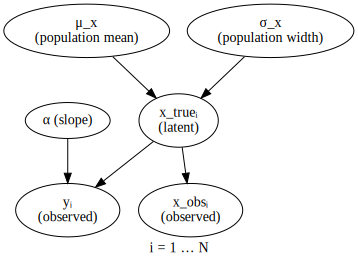

In [42]:
dot

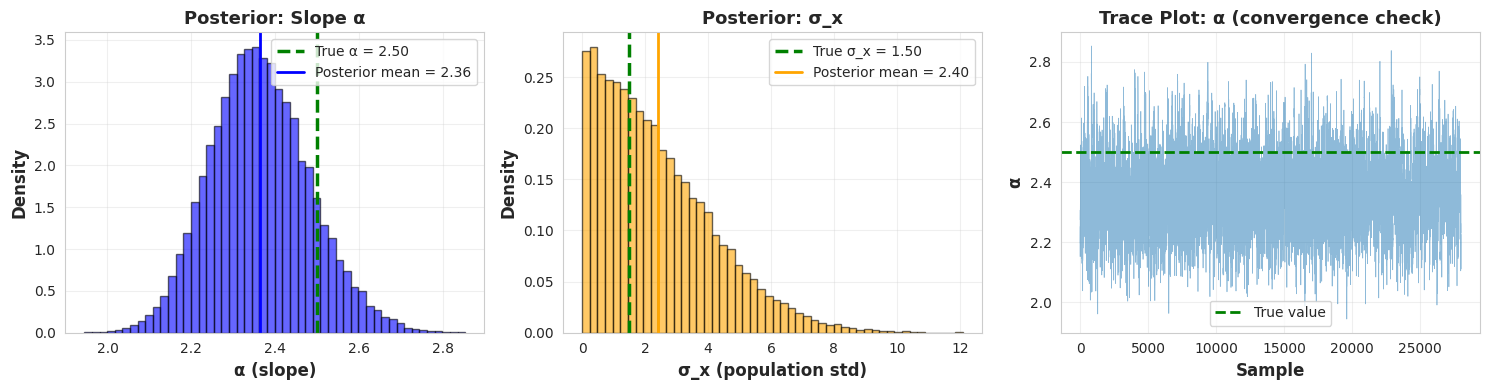


Posterior Summary Statistics:
Alpha (slope):
  Mean: 2.3636
  Std:  0.1189
  95% CI: [2.1464, 2.6118]

Sigma_x (population std):
  Mean: 2.3978
  Std:  1.8239


In [65]:

# Plot posterior distributions for all parameters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Posterior for alpha (slope)
ax = axes[0]
ax.hist(bhm_samples['alpha'], bins=50, density=True, alpha=0.6, 
    color='blue', edgecolor='black')
ax.axvline(data['alpha_true'], color='green', linestyle='--', linewidth=2.5,
      label=f'True α = {data["alpha_true"]:.2f}')
ax.axvline(comparison['alpha_bhm_mean'], color='blue', linestyle='-', linewidth=2,
      label=f'Posterior mean = {comparison["alpha_bhm_mean"]:.2f}')
ax.set_xlabel('α (slope)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Posterior: Slope α', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Posterior for sigma_x
ax = axes[1]
sigma_x_samples = bhm_samples['sigma_x'].flatten()
ax.hist(sigma_x_samples, bins=50, density=True, alpha=0.6,
    color='orange', edgecolor='black')
ax.axvline(data['sigma_x'], color='green', linestyle='--', linewidth=2.5,
      label=f'True σ_x = {data["sigma_x"]:.2f}')
ax.axvline(np.mean(sigma_x_samples), color='orange', linestyle='-', linewidth=2,
      label=f'Posterior mean = {np.mean(sigma_x_samples):.2f}')
ax.set_xlabel('σ_x (population std)', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Posterior: σ_x', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Trace plot for alpha (convergence check)
ax = axes[2]
alpha_samples = bhm_samples['alpha']
ax.plot(alpha_samples, alpha=0.5, linewidth=0.5)
ax.axhline(data['alpha_true'], color='green', linestyle='--', linewidth=2,
      label='True value')
ax.set_xlabel('Sample', fontsize=12, fontweight='bold')
ax.set_ylabel('α', fontsize=12, fontweight='bold')
ax.set_title('Trace Plot: α (convergence check)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nPosterior Summary Statistics:")
print("=" * 60)
print(f"Alpha (slope):")
print(f"  Mean: {comparison['alpha_bhm_mean']:.4f}")
print(f"  Std:  {np.std(bhm_samples['alpha']):.4f}")
print(f"  95% CI: [{comparison['alpha_bhm_ci'][0]:.4f}, {comparison['alpha_bhm_ci'][1]:.4f}]")
print(f"\nSigma_x (population std):")
print(f"  Mean: {np.mean(sigma_x_samples):.4f}")
print(f"  Std:  {np.std(sigma_x_samples):.4f}")

In [33]:
bhm_samples

{'alpha': Array([2.5004961, 2.6392834, 2.5063038, ..., 2.1880305, 2.304919 ,
        2.6032636], dtype=float32),
 'mu_x': Array([-0.0535435 ,  0.07497957, -0.10124659, ..., -0.0368754 ,
        -0.03200428, -0.0361829 ], dtype=float32),
 'sigma_x': Array([2.185363  , 1.6067026 , 1.4466528 , ..., 2.3500562 , 0.95916617,
        1.459816  ], dtype=float32),
 'x_true': Array([[ 0.6072781 ,  0.22353098,  0.73962456, ...,  0.43697032,
          0.13170627, -0.97166544],
        [ 0.40758088, -0.1750815 ,  0.8349213 , ...,  0.20859002,
         -0.13024887, -0.739032  ],
        [ 0.5277231 ,  0.08485043,  0.70911384, ...,  0.51915216,
          0.17315227, -0.9361603 ],
        ...,
        [ 0.84472156,  0.10644443,  0.81251466, ...,  0.17526002,
          0.06097436, -0.9414045 ],
        [ 0.11446372,  0.07117369,  0.90658516, ...,  0.67018324,
          0.13822915, -0.9675308 ],
        [ 0.9469525 , -0.13497621,  0.77867436, ...,  0.12980735,
         -0.11549748, -0.83196276]], dtype=

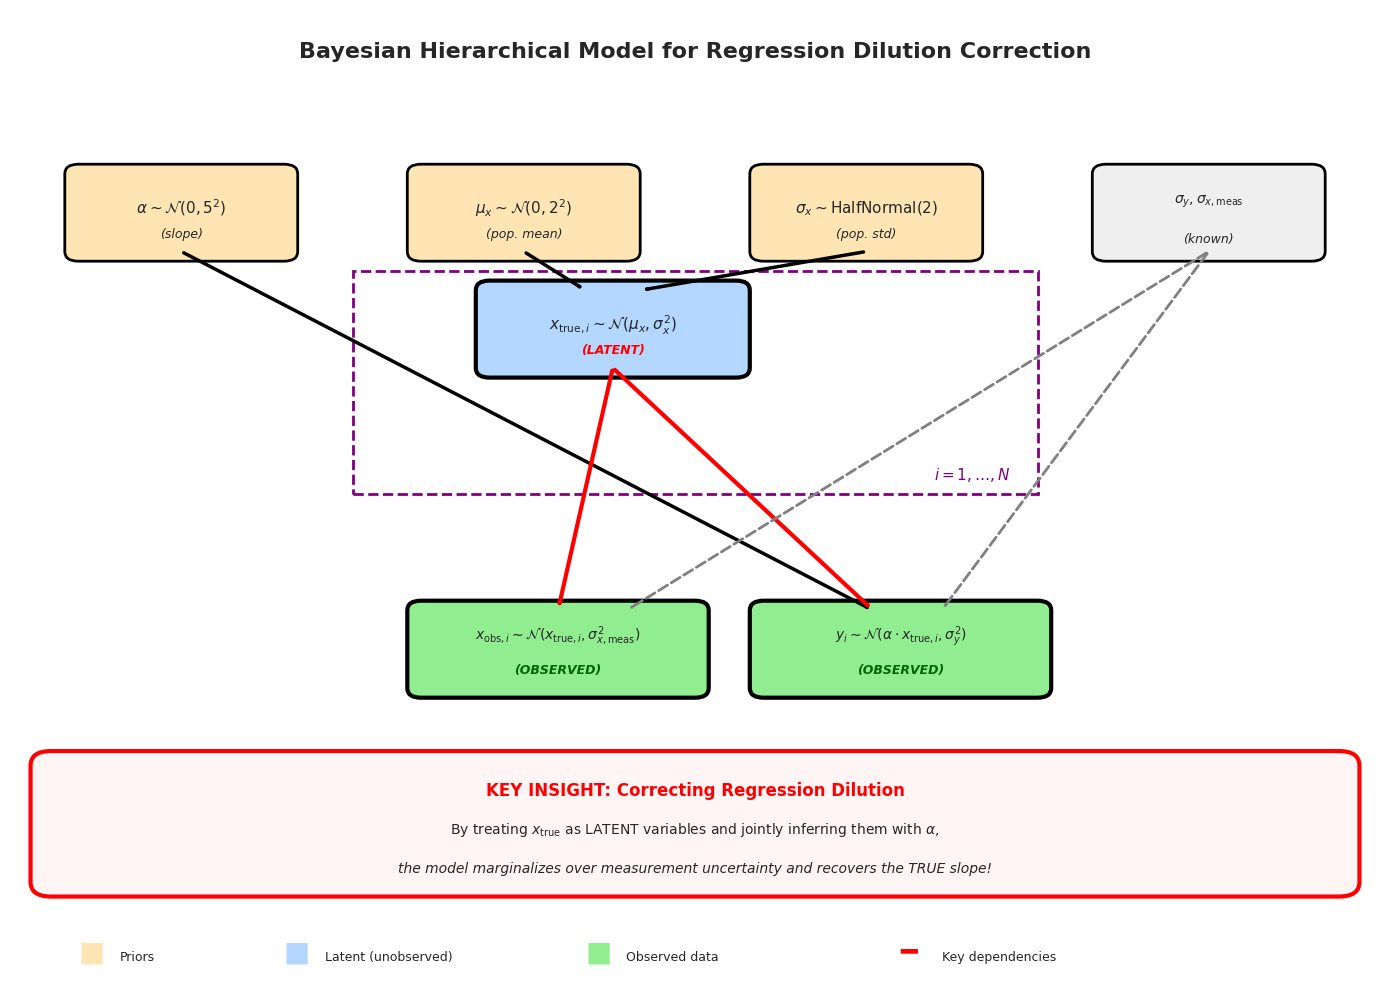


UNDERSTANDING THE BAYESIAN HIERARCHICAL MODEL DIAGRAM

STRUCTURE:
-----------
Top Level (Priors):
  • α: The slope we want to estimate (unknown parameter)
  • μ_x, σ_x: Population distribution of true x values (unknown)
  • σ_y, σ_x,meas: Known measurement error standard deviations

Middle Level (Latent Variables - THE KEY!):
  • x_true[i]: The TRUE (unobserved) x values for each data point
  • These are sampled from N(μ_x, σ_x²)
  • We never observe these directly!

Bottom Level (Observed Data):
  • x_obs[i]: What we actually measure (x_true + measurement error)
  • y[i]: The response variable (depends on x_true, not x_obs!)

RED ARROWS = Critical dependencies that correct the bias:
  • x_true → x_obs: Measurement model
  • x_true → y: True relationship (this is what we care about!)
  • α → y: The slope parameter affects y through x_true

WHY THIS WORKS:
---------------
Traditional regression uses x_obs directly, ignoring measurement error.

This BHM:
1. Says "x_obs is noisy; let's i

In [47]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'Bayesian Hierarchical Model for Regression Dilution Correction', 
    fontsize=16, fontweight='bold', ha='center')

# Color scheme
color_prior = '#FFE5B4'  # Peach for priors
color_latent = '#B4D7FF'  # Light blue for latent variables
color_observed = '#90EE90'  # Light green for observed data
color_param = '#FFB4C8'  # Pink for parameters

# Level 1: Hyperpriors and Priors
y_level1 = 7.5

# Prior for alpha (slope)
box1 = FancyBboxPatch((0.5, y_level1), 1.5, 0.8, 
               boxstyle="round,pad=0.1", 
               edgecolor='black', facecolor=color_prior, linewidth=2)
ax.add_patch(box1)
ax.text(1.25, y_level1 + 0.4, r'$\alpha \sim \mathcal{N}(0, 5^2)$', 
    fontsize=11, ha='center', fontweight='bold')
ax.text(1.25, y_level1 + 0.15, '(slope)', fontsize=9, ha='center', style='italic')

# Prior for mu_x
box2 = FancyBboxPatch((3, y_level1), 1.5, 0.8,
               boxstyle="round,pad=0.1",
               edgecolor='black', facecolor=color_prior, linewidth=2)
ax.add_patch(box2)
ax.text(3.75, y_level1 + 0.4, r'$\mu_x \sim \mathcal{N}(0, 2^2)$',
    fontsize=11, ha='center', fontweight='bold')
ax.text(3.75, y_level1 + 0.15, '(pop. mean)', fontsize=9, ha='center', style='italic')

# Prior for sigma_x
box3 = FancyBboxPatch((5.5, y_level1), 1.5, 0.8,
               boxstyle="round,pad=0.1",
               edgecolor='black', facecolor=color_prior, linewidth=2)
ax.add_patch(box3)
ax.text(6.25, y_level1 + 0.4, r'$\sigma_x \sim \text{HalfNormal}(2)$',
    fontsize=11, ha='center', fontweight='bold')
ax.text(6.25, y_level1 + 0.15, '(pop. std)', fontsize=9, ha='center', style='italic')

# Known parameters
box4 = FancyBboxPatch((8, y_level1), 1.5, 0.8,
               boxstyle="round,pad=0.1",
               edgecolor='black', facecolor='#EFEFEF', linewidth=2)
ax.add_patch(box4)
ax.text(8.75, y_level1 + 0.5, r'$\sigma_y, \sigma_{x,\text{meas}}$',
    fontsize=10, ha='center', fontweight='bold')
ax.text(8.75, y_level1 + 0.1, '(known)', fontsize=9, ha='center', style='italic')

# Level 2: Latent variables (the key!)
y_level2 = 5.5

# Plate notation for i = 1, ..., n
plate_x = 2.5
plate_y = y_level2 - 0.5
plate_w = 5
plate_h = 2.3
plate_rect = mpatches.Rectangle((plate_x, plate_y), plate_w, plate_h,
                 linewidth=2, linestyle='--',
                 edgecolor='purple', facecolor='none')
ax.add_patch(plate_rect)
ax.text(plate_x + plate_w - 0.2, plate_y + 0.15, 
    r'$i = 1, \ldots, N$', fontsize=11, ha='right', 
    style='italic', color='purple', fontweight='bold')

# x_true (latent)
box5 = FancyBboxPatch((3.5, y_level2 + 0.8), 1.8, 0.8,
               boxstyle="round,pad=0.1",
               edgecolor='black', facecolor=color_latent, linewidth=3)
ax.add_patch(box5)
ax.text(4.4, y_level2 + 1.2, r'$x_{\text{true},i} \sim \mathcal{N}(\mu_x, \sigma_x^2)$',
    fontsize=11, ha='center', fontweight='bold')
ax.text(4.4, y_level2 + 0.95, '(LATENT)', fontsize=9, ha='center', 
    style='italic', color='red', fontweight='bold')

# Level 3: Observed data
y_level3 = 3

# x_obs (observed)
box6 = FancyBboxPatch((3, y_level3), 2, 0.8,
               boxstyle="round,pad=0.1",
               edgecolor='black', facecolor=color_observed, linewidth=3)
ax.add_patch(box6)
ax.text(4, y_level3 + 0.5, r'$x_{\text{obs},i} \sim \mathcal{N}(x_{\text{true},i}, \sigma_{x,\text{meas}}^2)$',
    fontsize=10, ha='center', fontweight='bold')
ax.text(4, y_level3 + 0.15, '(OBSERVED)', fontsize=9, ha='center',
    style='italic', color='darkgreen', fontweight='bold')

# y_obs (observed)
box7 = FancyBboxPatch((5.5, y_level3), 2, 0.8,
               boxstyle="round,pad=0.1",
               edgecolor='black', facecolor=color_observed, linewidth=3)
ax.add_patch(box7)
ax.text(6.5, y_level3 + 0.5, r'$y_i \sim \mathcal{N}(\alpha \cdot x_{\text{true},i}, \sigma_y^2)$',
    fontsize=10, ha='center', fontweight='bold')
ax.text(6.5, y_level3 + 0.15, '(OBSERVED)', fontsize=9, ha='center',
    style='italic', color='darkgreen', fontweight='bold')

# Arrows showing dependencies
arrow_style = dict(arrowstyle='->', lw=2.5, color='black')
arrow_style_red = dict(arrowstyle='->', lw=3, color='red')

# alpha -> y
arrow1 = FancyArrowPatch((1.25, y_level1), (6.3, y_level3 + 0.8),
             **arrow_style)
ax.add_patch(arrow1)

# mu_x -> x_true
arrow2 = FancyArrowPatch((3.75, y_level1), (4.2, y_level2 + 1.6),
             **arrow_style)
ax.add_patch(arrow2)

# sigma_x -> x_true
arrow3 = FancyArrowPatch((6.25, y_level1), (4.6, y_level2 + 1.6),
             **arrow_style)
ax.add_patch(arrow3)

# x_true -> x_obs (KEY CONNECTION)
arrow4 = FancyArrowPatch((4.4, y_level2 + 0.8), (4, y_level3 + 0.8),
             **arrow_style_red)
ax.add_patch(arrow4)

# x_true -> y (KEY CONNECTION)
arrow5 = FancyArrowPatch((4.4, y_level2 + 0.8), (6.3, y_level3 + 0.8),
             **arrow_style_red)
ax.add_patch(arrow5)

# sigma_x_meas -> x_obs
arrow6 = FancyArrowPatch((8.75, y_level1), (4.5, y_level3 + 0.8),
             **dict(arrowstyle='->', lw=2, color='gray', linestyle='dashed'))
ax.add_patch(arrow6)

# sigma_y -> y
arrow7 = FancyArrowPatch((8.75, y_level1), (6.8, y_level3 + 0.8),
             **dict(arrowstyle='->', lw=2, color='gray', linestyle='dashed'))
ax.add_patch(arrow7)

# Add explanatory text boxes
y_explain = 1

# Key insight box
insight_box = FancyBboxPatch((0.3, y_explain), 9.4, 1.2,
                 boxstyle="round,pad=0.15",
                 edgecolor='red', facecolor='#FFF5F5', 
                 linewidth=3, linestyle='-')
ax.add_patch(insight_box)

ax.text(5, y_explain + 0.9, 'KEY INSIGHT: Correcting Regression Dilution',
    fontsize=12, ha='center', fontweight='bold', color='red')

ax.text(5, y_explain + 0.5, 
    r'By treating $x_{\text{true}}$ as LATENT variables and jointly inferring them with $\alpha$,',
    fontsize=10, ha='center')

ax.text(5, y_explain + 0.1,
    r'the model marginalizes over measurement uncertainty and recovers the TRUE slope!',
    fontsize=10, ha='center', style='italic')

# Legend
legend_y = 0.2
ax.text(0.5, legend_y, '■', fontsize=20, color=color_prior)
ax.text(0.8, legend_y, 'Priors', fontsize=9)

ax.text(2, legend_y, '■', fontsize=20, color=color_latent)
ax.text(2.3, legend_y, 'Latent (unobserved)', fontsize=9)

ax.text(4.2, legend_y, '■', fontsize=20, color=color_observed)
ax.text(4.5, legend_y, 'Observed data', fontsize=9)

ax.text(6.5, legend_y, '━', fontsize=20, color='red')
ax.text(6.8, legend_y, 'Key dependencies', fontsize=9)

plt.tight_layout()
plt.show()

# Print explanation
print("\n" + "=" * 80)
print("UNDERSTANDING THE BAYESIAN HIERARCHICAL MODEL DIAGRAM")
print("=" * 80)
print("""
STRUCTURE:
-----------
Top Level (Priors):
  • α: The slope we want to estimate (unknown parameter)
  • μ_x, σ_x: Population distribution of true x values (unknown)
  • σ_y, σ_x,meas: Known measurement error standard deviations

Middle Level (Latent Variables - THE KEY!):
  • x_true[i]: The TRUE (unobserved) x values for each data point
  • These are sampled from N(μ_x, σ_x²)
  • We never observe these directly!

Bottom Level (Observed Data):
  • x_obs[i]: What we actually measure (x_true + measurement error)
  • y[i]: The response variable (depends on x_true, not x_obs!)

RED ARROWS = Critical dependencies that correct the bias:
  • x_true → x_obs: Measurement model
  • x_true → y: True relationship (this is what we care about!)
  • α → y: The slope parameter affects y through x_true

WHY THIS WORKS:
---------------
Traditional regression uses x_obs directly, ignoring measurement error.

This BHM:
1. Says "x_obs is noisy; let's infer the true x values"
2. Uses BOTH x_obs and y to jointly infer x_true and α
3. Marginalizes over uncertainty in x_true during MCMC sampling
4. This naturally corrects the attenuation bias!

The posterior P(α | x_obs, y) correctly accounts for measurement error,
recovering the true slope instead of the attenuated naive estimate.
""")

In [49]:
inference_data

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

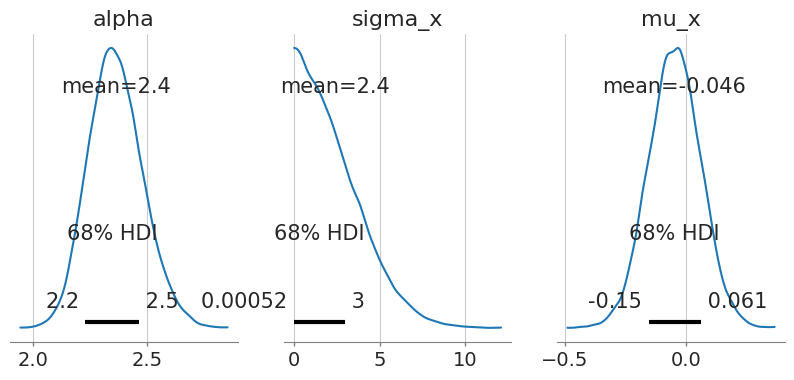

In [52]:
import arviz as az

# Convert NumPyro MCMC results to ArviZ InferenceData for plotting
inference_data = az.from_numpyro(mcmc)

# Plot posterior distributions
az.plot_posterior(
    inference_data,
    var_names=['alpha', 'sigma_x', 'mu_x'],
    
    hdi_prob=0.68,
    figsize=(10, 4)
)
plt.show()


In [86]:
bhm_samples

{'alpha': Array([2.4479222, 2.5526693, 2.4332998, ..., 2.0375993, 2.128685 ,
        2.4021447], dtype=float32),
 'mu_x': Array([-0.07004755,  0.09952211, -0.1089    , ..., -0.02462129,
        -0.02459971, -0.0436281 ], dtype=float32),
 'sigma_x': Array([3.2563891, 2.5070932, 2.193151 , ..., 3.2064242, 1.4688205,
        2.5543866], dtype=float32),
 'x_true': Array([[ 0.6305826 ,  0.01925289,  0.7548173 , ...,  0.46297678,
          0.28726143, -0.84136295],
        [ 0.53124976,  0.05930611,  0.8519458 , ...,  0.2655581 ,
         -0.24066664, -0.8971541 ],
        [ 0.58001965, -0.07757697,  0.82615143, ...,  0.5556845 ,
          0.31752306, -0.8044889 ],
        ...,
        [ 0.94868857,  0.15210639,  0.9087509 , ...,  0.23969577,
          0.04521019, -0.9717462 ],
        [ 0.22485498,  0.14447361,  0.93454355, ...,  0.739454  ,
          0.19330142, -1.0544763 ],
        [ 1.1703084 , -0.0331079 ,  0.9131125 , ...,  0.330666  ,
         -0.16046005, -1.0260125 ]], dtype=float3

(array([ 1.,  7., 17., 29., 37., 53., 31., 13.,  9.,  3.]),
 array([-2.83495831, -2.2875886 , -1.74021864, -1.1928488 , -0.64547896,
        -0.09810901,  0.44926071,  0.99663043,  1.54400039,  2.09137034,
         2.6387403 ]),
 <BarContainer object of 10 artists>)

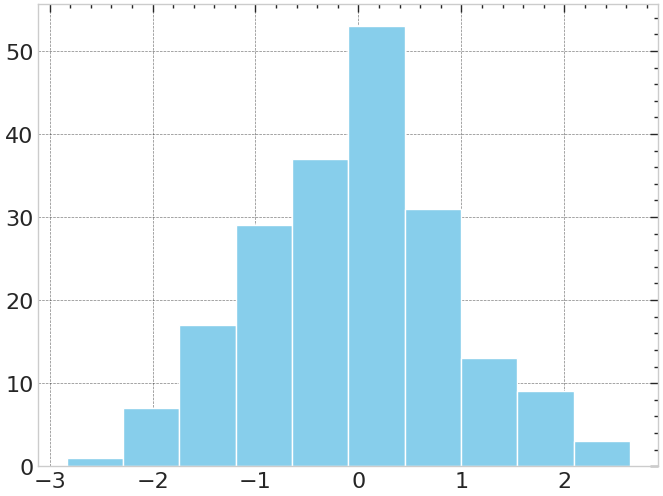

In [98]:
plt.hist(np.median(bhm_samples['x_true'], axis=0), color='skyblue',bins = 10)

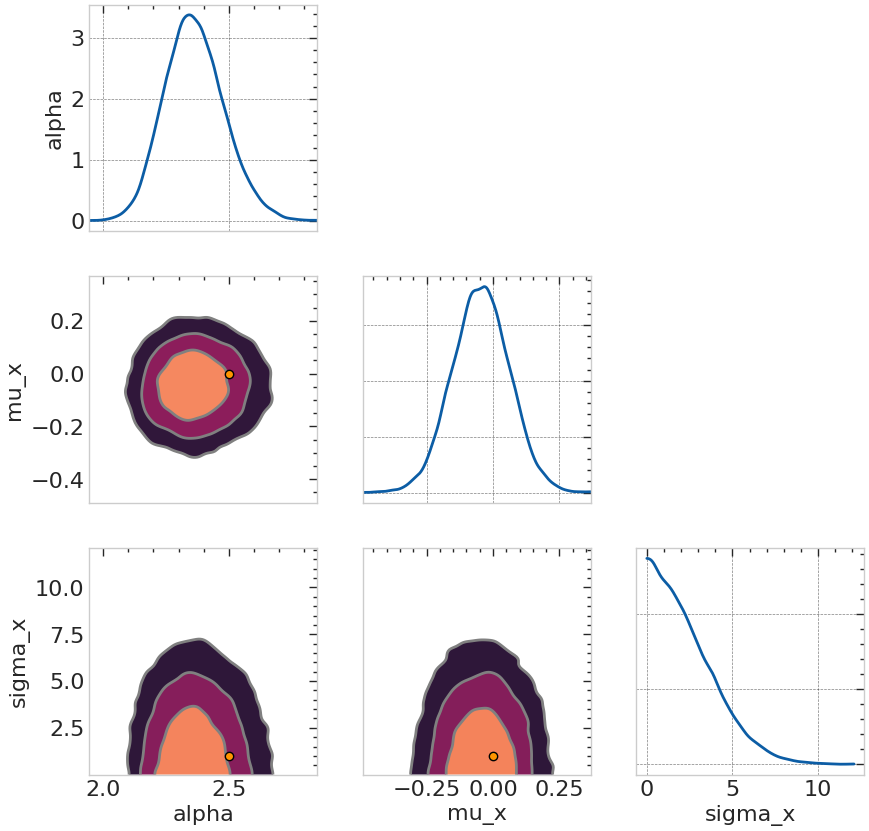

In [85]:
az.plot_pair(
    inference_data,
    var_names=['alpha', 'mu_x','sigma_x'],
    kind = 'kde',
    reference_values={
        'alpha': data['alpha_true'],
        'mu_x': 0,
        'sigma_x': data['sigma_x']
    },
    figsize=(10, 10),
    marginals=True
)
plt.show()

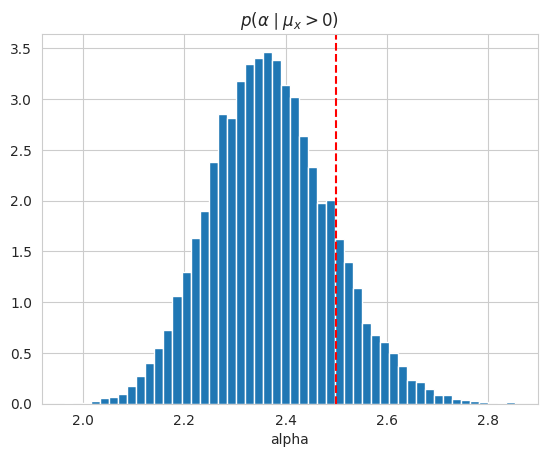

In [67]:
mask = inference_data.posterior['mu_x'] > 0

alpha_cond = inference_data.posterior['alpha'].where(mask).values.flatten()

plt.hist(alpha_cond, bins=50, density=True)
plt.axvline(data['alpha_true'], color='r', ls='--')
plt.xlabel("alpha")
plt.title(r"$p(\alpha \mid \mu_x > 0)$")
plt.show()

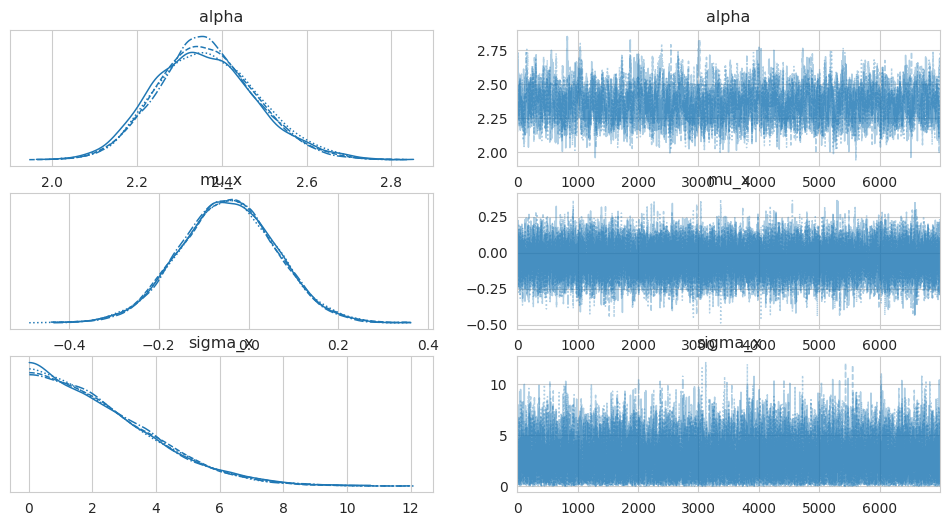

In [68]:
az.plot_trace(
    inference_data,
    var_names=['alpha', 'mu_x', 'sigma_x']
)
plt.show()